# Wind Curl Comparison between HRDPS and CaSR

In this notebook, we compare the spatial and temporal difference of wind speed and wind curl between HRDPS and CaSR. The wind velocity and the curl affect the wind-driven mixing and upwelling.

We should calculate wind stress curl $\tau$ instead of wind curl, as low resolution may amplify the impact of non-linearity.

See https://journals.ametsoc.org/view/journals/clim/20/23/2007jcli1825.1.xml for the equation to compute the wind stress $\tau$. 

See https://glossary.ametsoc.org/wiki/wind-stress-curl/ for the definition of the curl of wind stress.

## Basic Preparation



In [ ]:
# path

path_casr_u='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc'

path_casr_v='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc'

import sys

sys.path.append("/home/jqiu/analysis-junqi/Tools-Junqi")

import junqi_nctool as jqnc



In [ ]:
# an example of hrdps path
path_hrdps_u=jqnc.nc_path('wind_u',time='2018-01-01',resolution='hourly')

# display variables

jqnc.nc_disp(path_casr_u)

### NetCDF Summary

*Path: : `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc`*

#### Dimensions

Dimension,Size
time,149040
rlat,105
rlon,70


#### Variables

Name,Shape,Dimensions
rotated_pole,(),scalar
CaSR_v3.2_P_UUC_10m,"(149040, 105, 70)","time, rlat, rlon"
time,"(149040,)",time
lon,"(105, 70)","rlat, rlon"
lat,"(105, 70)","rlat, rlon"
rlon,"(70,)",rlon
rlat,"(105,)",rlat


In [2]:
# display variables

jqnc.nc_disp(path_casr_v)

### NetCDF Summary

*Path: : `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc`*

#### Dimensions

Dimension,Size
time,149040
rlat,105
rlon,70


#### Variables

Name,Shape,Dimensions
rotated_pole,(),scalar
CaSR_v3.2_P_VVC_10m,"(149040, 105, 70)","time, rlat, rlon"
time,"(149040,)",time
lon,"(105, 70)","rlat, rlon"
lat,"(105, 70)","rlat, rlon"
rlon,"(70,)",rlon
rlat,"(105,)",rlat


In [7]:
# display variables

jqnc.nc_disp(path_hrdps_u)

### NetCDF Summary

*Path: : `/results/forcing/atmospheric/GEM2.5/operational/ops_y2018m01d01.nc`*

#### Dimensions

Dimension,Size
time_counter,24
y,266
x,256


#### Variables

Name,Shape,Dimensions
atmpres,"(24, 266, 256)","time_counter, y, x"
nav_lat,"(266, 256)","y, x"
nav_lon,"(266, 256)","y, x"
percentcloud,"(24, 266, 256)","time_counter, y, x"
precip,"(24, 266, 256)","time_counter, y, x"
qair,"(24, 266, 256)","time_counter, y, x"
solar,"(24, 266, 256)","time_counter, y, x"
tair,"(24, 266, 256)","time_counter, y, x"
therm_rad,"(24, 266, 256)","time_counter, y, x"
u_wind,"(24, 266, 256)","time_counter, y, x"


### HRDPS

In [6]:
# combine hrdps dataset

import xarray as xr

def variables(ds):
    return ds[['u_wind','v_wind','nav_lat','nav_lon']]

ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})

/tmp/ipykernel_2603195/1827557314.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})


In [18]:
# check combined hrdps dataset

print(ds_hrdps)

<xarray.Dataset> Size: 14GB
Dimensions:       (time_counter: 8760, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 70kB 2018-01-01 ... 2018-12-3...
  * x             (x) float64 2kB 0.0 2.5e+03 5e+03 ... 6.35e+05 6.375e+05
  * y             (y) float64 2kB 0.0 2.5e+03 5e+03 ... 6.6e+05 6.625e+05
Data variables:
    u_wind        (time_counter, y, x) float32 2GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
    v_wind        (time_counter, y, x) float32 2GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
    nav_lat       (time_counter, y, x) float64 5GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
    nav_lon       (time_counter, y, x) float64 5GB dask.array<chunksize=(24, 266, 256), meta=np.ndarray>
Attributes:
    Conventions:          CF-1.0
    History:              Mon Jan  1 10:36:51 2018: ncks -4 -L4 -O /results/f...
    GRIB2_grid_template:  20
    NCO:                  4.4.2


In [7]:
# calculate absolute velocity

import numpy as np
from dask.distributed import Client

# real time progress (recommended by Gemini)
client = Client() 
print(f"Dask Dashboard link: {client.dashboard_link}")

velocity_hrdps=np.sqrt(ds_hrdps['u_wind']**2+ds_hrdps['v_wind']**2)

# use meter to calculate du/dy and dv/dx

tau_u=ds_hrdps['u_wind']*np.absolute(ds_hrdps['u_wind'])
tau_v=ds_hrdps['v_wind']*np.absolute(ds_hrdps['v_wind'])
ws_curl_hrdps=-tau_u.differentiate('y')+tau_v.differentiate('x')

# calculate mean and variance

mean_velocity_hrdps=velocity_hrdps.mean(dim='time_counter')
mean_ws_curl_hrdps=ws_curl_hrdps.mean(dim='time_counter')
var_ws_curl_hrdps=ws_curl_hrdps.var(dim='time_counter')

mean_hrdps_2018=xr.Dataset({
    'mean_velocity': mean_velocity_hrdps,
    'mean_ws_curl': mean_ws_curl_hrdps,
    'var_ws_curl': var_ws_curl_hrdps,
    'nav_lat': ds_hrdps['nav_lat'].isel(time_counter=0),
    'nav_lon': ds_hrdps['nav_lon'].isel(time_counter=0)
})

# save

output_path = "hrdps_2018_wind_and_curl.nc"

mean_hrdps_2018.to_netcdf(output_path)

Dask Dashboard link: http://127.0.0.1:8787/status


**What's Fun Here**

1. `x` and `y` here represent the length in meter, so we could simply use `differentiate('x')`. However, note that the first grid point `x[0]=0`. Be careful with the boundary of the final results.

2. Use command `top` to see the CPU capacity. 

3. `parallel=True` will activate parallel computation. 

### Native CaSR

In [8]:
# CaSR extraction
import xarray as xr
import numpy as np

ds_casr_u=xr.open_dataset(path_casr_u)

ds_casr_v=xr.open_dataset(path_casr_v)

# use 'CaSR_v3.2_P_VVC_10m' and 'time'

ds_casr_u_2018=ds_casr_u.sel(time=slice('2018-01-01','2018-12-31'))*0.5144

ds_casr_v_2018=ds_casr_v.sel(time=slice('2018-01-01','2018-12-31'))*0.5144

# print(ds_casr_u_2018)
ds_casr=xr.merge([ds_casr_u_2018['CaSR_v3.2_P_UUC_10m'],ds_casr_v_2018['CaSR_v3.2_P_VVC_10m']])

/tmp/ipykernel_2603195/2760346390.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_casr=xr.merge([ds_casr_u_2018['CaSR_v3.2_P_UUC_10m'],ds_casr_v_2018['CaSR_v3.2_P_VVC_10m']])
/tmp/ipykernel_2603195/2760346390.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_casr=xr.merge([ds_casr_u_2018['CaSR_v3.2_P_UUC_10m'],ds_casr_v_

In [9]:
print(ds_casr)

<xarray.Dataset> Size: 515MB
Dimensions:              (time: 8760, rlat: 105, rlon: 70)
Coordinates:
  * time                 (time) datetime64[ns] 70kB 2018-01-01 ... 2018-12-31...
    lon                  (rlat, rlon) float32 29kB 235.9 236.0 ... 238.0 238.2
    lat                  (rlat, rlon) float32 29kB 43.38 43.42 ... 54.46 54.5
  * rlon                 (rlon) float64 560B -22.8 -22.71 ... -16.68 -16.59
  * rlat                 (rlat) float64 840B -9.45 -9.36 -9.27 ... -0.18 -0.09
Data variables:
    CaSR_v3.2_P_UUC_10m  (time, rlat, rlon) float32 258MB 0.4814 ... -0.2914
    CaSR_v3.2_P_VVC_10m  (time, rlat, rlon) float32 258MB -0.234 ... 0.6501


In [10]:
# calculate velocity and vorticity

import numpy as np

velocity_casr=np.sqrt(ds_casr['CaSR_v3.2_P_UUC_10m']**2+ds_casr['CaSR_v3.2_P_VVC_10m']**2)

# use meter to calculate du/dy and dv/dx

# radius of the earth

R=6371000 # m

tau_u=ds_casr['CaSR_v3.2_P_UUC_10m']*np.absolute(ds_casr['CaSR_v3.2_P_UUC_10m'])
tau_v=ds_casr['CaSR_v3.2_P_VVC_10m']*np.absolute(ds_casr['CaSR_v3.2_P_VVC_10m'])

dtau_u_dlat=tau_u.differentiate('rlat')
dtau_v_dlon=tau_v.differentiate('rlon')

# from latitude to meter

dy_dlat=R * (np.pi/180.0)

dx_dlon= R * (np.pi / 180.0) * np.cos(np.deg2rad(ds_casr['rlat']))

dtau_u_dy = dtau_u_dlat / dy_dlat
dtau_v_dx = dtau_v_dlon / dx_dlon

ws_curl_casr = dtau_v_dx - dtau_u_dy

mean_velocity_casr=velocity_casr.mean(dim='time')
mean_ws_curl_casr=ws_curl_casr.mean(dim='time')
var_ws_curl_casr=ws_curl_casr.var(dim='time')

mean_casr_2018=xr.Dataset({
    'mean_velocity': mean_velocity_casr,
    'mean_ws_casr': mean_ws_curl_casr,
    'var_ws_casr': var_ws_curl_casr
})


In [11]:
# save 

output_path = "casr_2018_wind_and_curl.nc"

mean_casr_2018.to_netcdf(output_path)

### Coarsened HRDPS

HRDPS is coarsened by integrating every 4 grids for a 10 km resolution, the same as CaSR data. There are many options including down-sampling (simply picking points), smoothing and coarsening. We believe that the coarsened grid could represent the 10 km region, despite there may be land/sea problem.

In [12]:
# combine hrdps dataset

import xarray as xr

def variables(ds):
    return ds[['u_wind','v_wind','nav_lat','nav_lon']]

ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})

# smooth wind speed

ds_hrdps_coarsened = ds_hrdps.coarsen(
    x=4, y=4, boundary='trim'
).mean()

# calculate absolute velocity

import numpy as np
from dask.distributed import Client

# real time progress (recommended by Gemini)
client = Client() 
print(f"Dask Dashboard link: {client.dashboard_link}")

velocity_hrdps=np.sqrt(ds_hrdps_coarsened['u_wind']**2+ds_hrdps_coarsened['v_wind']**2)

# use meter to calculate du/dy and dv/dx

tau_u=ds_hrdps_coarsened['u_wind']*np.absolute(ds_hrdps_coarsened['u_wind'])
tau_v=ds_hrdps_coarsened['v_wind']*np.absolute(ds_hrdps_coarsened['v_wind'])
ws_curl_hrdps=-tau_u.differentiate('y')+tau_v.differentiate('x')

# calculate mean and variance

mean_velocity_hrdps=velocity_hrdps.mean(dim='time_counter')
mean_ws_curl_hrdps=ws_curl_hrdps.mean(dim='time_counter')
var_ws_curl_hrdps=ws_curl_hrdps.var(dim='time_counter')

mean_hrdps_2018=xr.Dataset({
    'mean_velocity': mean_velocity_hrdps,
    'mean_ws_curl': mean_ws_curl_hrdps,
    'var_ws_curl': var_ws_curl_hrdps,
    'nav_lat': ds_hrdps['nav_lat'].isel(time_counter=0),
    'nav_lon': ds_hrdps['nav_lon'].isel(time_counter=0)
})

# save

output_path = "hrdps_coarsened_2018_wind_and_curl.nc"

mean_hrdps_2018.to_netcdf(output_path)

/tmp/ipykernel_2603195/2379832284.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})
/home/jqiu/conda_envs/analysis-junqi/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37697 instead
  warnings.warn(


Dask Dashboard link: http://127.0.0.1:37697/status


## Visualization

In [1]:
# Path and reading

import xarray as xr


path_casr='casr_2018_wind_and_curl.nc'
path_hrdps='hrdps_2018_wind_and_curl.nc'
path_hrdps_coarsened='hrdps_coarsened_2018_wind_and_curl.nc'

ds_casr=xr.open_dataset(path_casr)
ds_hrdps=xr.open_dataset(path_hrdps)
ds_hrdps_coarsened=xr.open_dataset(path_hrdps_coarsened)



In [3]:
# inspect casr

print(ds_casr)

<xarray.Dataset> Size: 207kB
Dimensions:        (rlat: 105, rlon: 70)
Coordinates:
    lon            (rlat, rlon) float32 29kB ...
    lat            (rlat, rlon) float32 29kB ...
  * rlon           (rlon) float64 560B -22.8 -22.71 -22.62 ... -16.68 -16.59
  * rlat           (rlat) float64 840B -9.45 -9.36 -9.27 ... -0.27 -0.18 -0.09
Data variables:
    mean_velocity  (rlat, rlon) float32 29kB ...
    mean_ws_casr   (rlat, rlon) float64 59kB ...
    var_ws_casr    (rlat, rlon) float64 59kB ...


In [4]:
# inspect hrdps

print(ds_hrdps)

<xarray.Dataset> Size: 2MB
Dimensions:        (y: 266, x: 256)
Coordinates:
  * x              (x) float64 2kB 0.0 2.5e+03 5e+03 ... 6.35e+05 6.375e+05
  * y              (y) float64 2kB 0.0 2.5e+03 5e+03 ... 6.6e+05 6.625e+05
    time_counter   datetime64[ns] 8B ...
Data variables:
    mean_velocity  (y, x) float32 272kB ...
    mean_ws_curl   (y, x) float32 272kB ...
    var_ws_curl    (y, x) float32 272kB ...
    nav_lat        (y, x) float64 545kB ...
    nav_lon        (y, x) float64 545kB ...


In [5]:
# inspect hrdps_coarsened

print(ds_hrdps_coarsened)

<xarray.Dataset> Size: 3MB
Dimensions:        (y: 332, x: 320)
Coordinates:
  * x              (x) float64 3kB 0.0 2.5e+03 3.75e+03 ... 6.35e+05 6.375e+05
  * y              (y) float64 3kB 0.0 2.5e+03 3.75e+03 ... 6.6e+05 6.625e+05
    time_counter   datetime64[ns] 8B ...
Data variables:
    mean_velocity  (y, x) float32 425kB ...
    mean_ws_curl   (y, x) float32 425kB ...
    var_ws_curl    (y, x) float32 425kB ...
    nav_lat        (y, x) float64 850kB ...
    nav_lon        (y, x) float64 850kB ...


### HRDPS Visualization

In [9]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# cut out the 5 grids in the boundary
trim_n = 5

#  isel (integer selection) 
ds_trimmed = ds_hrdps.isel(x=slice(trim_n, -trim_n), y=slice(trim_n, -trim_n))

# print region
lon_min = float(ds_trimmed.nav_lon.min())
lon_max = float(ds_trimmed.nav_lon.max())
lat_min = float(ds_trimmed.nav_lat.min())
lat_max = float(ds_trimmed.nav_lat.max())


# print(f"Lon : {lon_min:.4f} to {lon_max:.4f}")
# print(f"Lat : {lat_min:.4f} to {lat_max:.4f}")


# lon and lat
lon = ds_trimmed.nav_lon.values
lat = ds_trimmed.nav_lat.values
vel = ds_trimmed.mean_velocity.values
curl = ds_trimmed.mean_ws_curl.values
var_curl = ds_trimmed.var_ws_curl.values


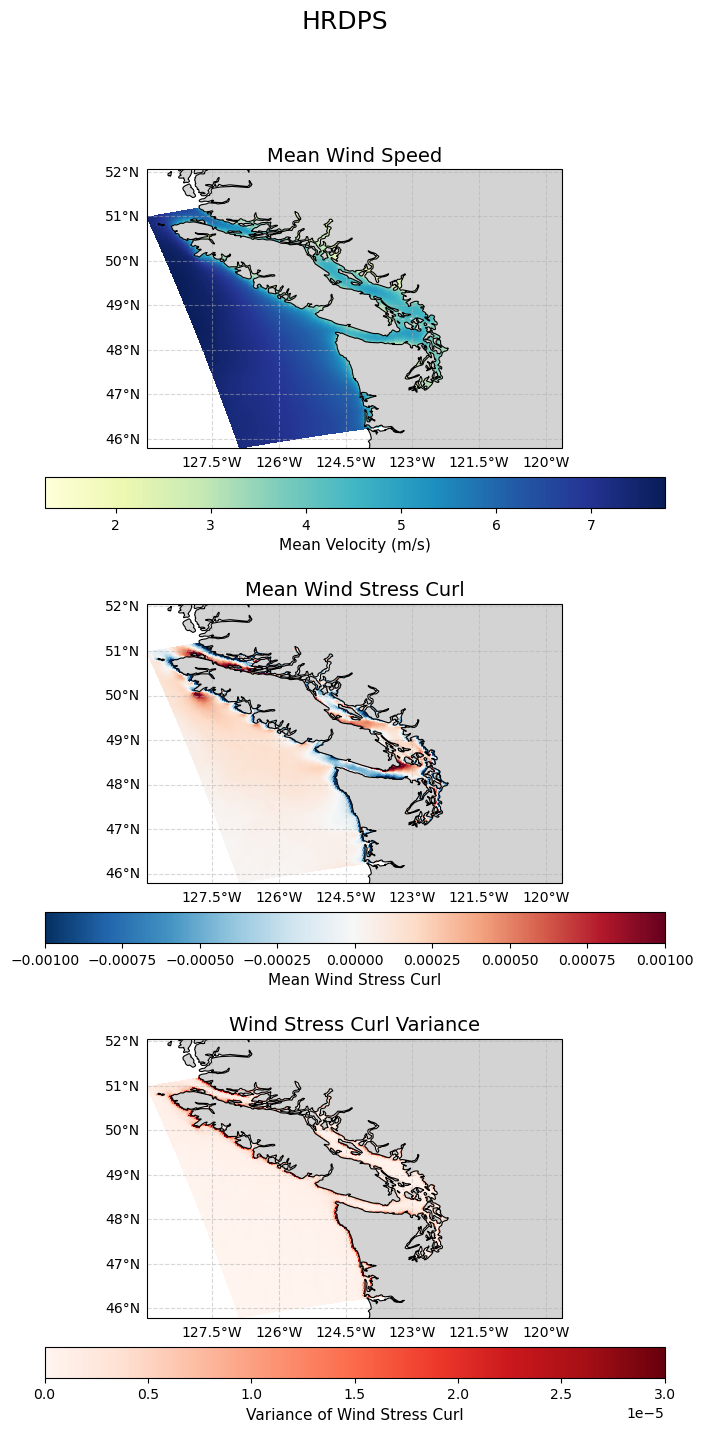

In [10]:

# visualization
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 16), subplot_kw={'projection': proj})

# map
def setup_map(ax):
    
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    
    # grid
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

# mean velocity
ax1 = axes[0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon, lat, vel, transform=proj, cmap='YlGnBu', shading='auto', zorder=1)
cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
cb1.set_label('Mean Velocity (m/s)', fontsize=11)
ax1.set_title('Mean Wind Speed', fontsize=14)

# mean wind stress curl
ax2 = axes[1]
setup_map(ax2)
vmax_curl = 0.001
pcm2 = ax2.pcolormesh(lon, lat, curl, transform=proj, cmap='RdBu_r', 
                      vmin=-vmax_curl, vmax=vmax_curl, shading='auto', zorder=1)
cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
cb2.set_label('Mean Wind Stress Curl', fontsize=11)
ax2.set_title('Mean Wind Stress Curl', fontsize=14)

# variance of wind stress curl
ax3 = axes[2]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon, lat, var_curl, transform=proj, cmap='Reds',vmin=0,vmax=0.00003, shading='auto', zorder=1)
cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
cb3.set_label('Variance of Wind Stress Curl', fontsize=11)
ax3.set_title('Wind Stress Curl Variance', fontsize=14)

plt.suptitle('HRDPS', fontsize=18)
plt.show()

### Coarsened HRDPS

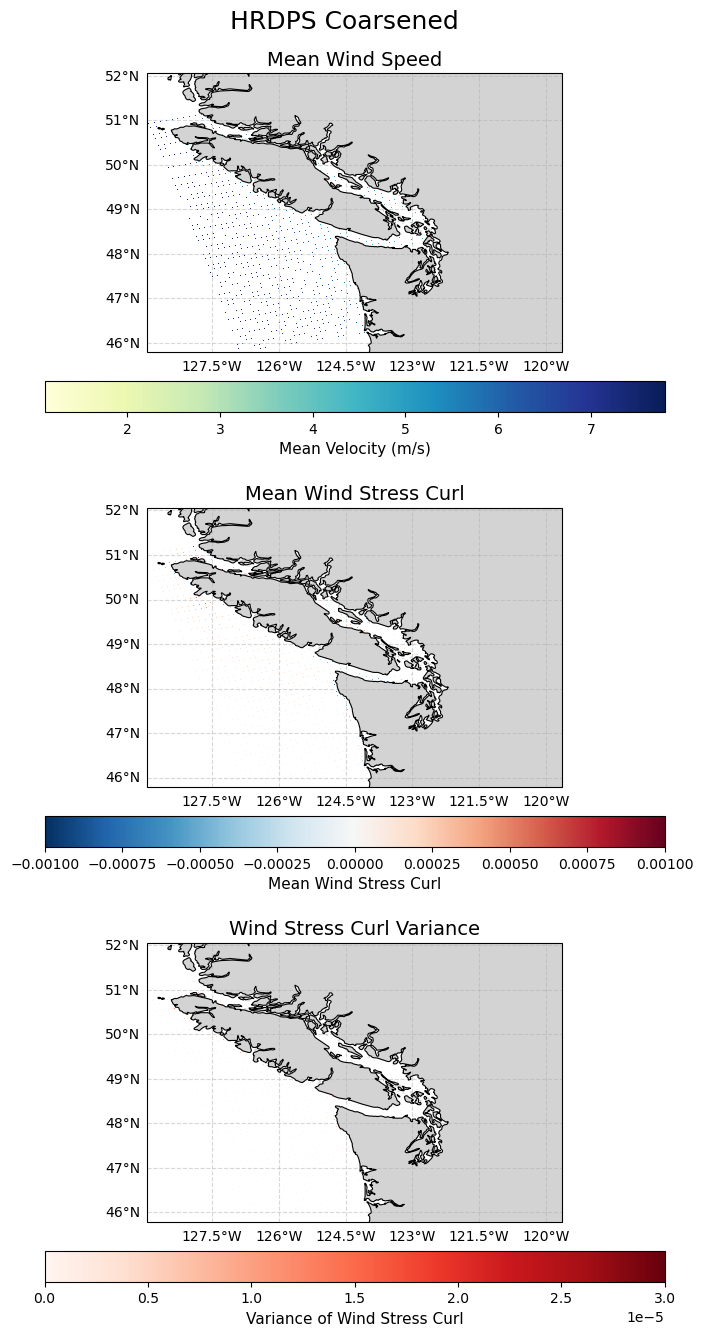

In [ ]:
# HRDPS Coarsened 

trim_n = 2
ds_coarsened_trimmed = ds_hrdps_coarsened.isel(x=slice(trim_n, -trim_n), y=slice(trim_n, -trim_n))

lon_c = ds_coarsened_trimmed.nav_lon.values
lat_c = ds_coarsened_trimmed.nav_lat.values
vel_c = ds_coarsened_trimmed.mean_velocity.values
curl_c = ds_coarsened_trimmed.mean_ws_curl.values
var_curl_c = ds_coarsened_trimmed.var_ws_curl.values



fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 16), subplot_kw={'projection': proj})

def setup_map(ax):
    # 这里使用的是全局的 lon_min, lon_max, lat_min, lat_max
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

# mean velocity
ax1 = axes[0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon_c, lat_c, vel_c, transform=proj, cmap='YlGnBu', shading='auto', zorder=1)
cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
cb1.set_label('Mean Velocity (m/s)', fontsize=11)
ax1.set_title('Mean Wind Speed', fontsize=14)

# mean wind stress curl
ax2 = axes[1]
setup_map(ax2)
pcm2 = ax2.pcolormesh(lon_c, lat_c, curl_c, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
cb2.set_label('Mean Wind Stress Curl', fontsize=11)
ax2.set_title('Mean Wind Stress Curl', fontsize=14)

# variance of wind stress curl
ax3 = axes[2]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon_c, lat_c, var_curl_c, transform=proj, cmap='Reds',
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
cb3.set_label('Variance of Wind Stress Curl', fontsize=11)
ax3.set_title('Wind Stress Curl Variance', fontsize=14)

plt.suptitle('HRDPS Coarsened', fontsize=18, y=0.92)
plt.show()

In [15]:
nan_lon = int(ds_hrdps_coarsened.nav_lon.isnull().sum())
nan_lat = int(ds_hrdps_coarsened.nav_lat.isnull().sum())
print(f"[坐标] nav_lon 中的 NaN 数量: {nan_lon}")
print(f"[坐标] nav_lat 中的 NaN 数量: {nan_lat}")

[坐标] nav_lon 中的 NaN 数量: 38144
[坐标] nav_lat 中的 NaN 数量: 38144


### CaSR

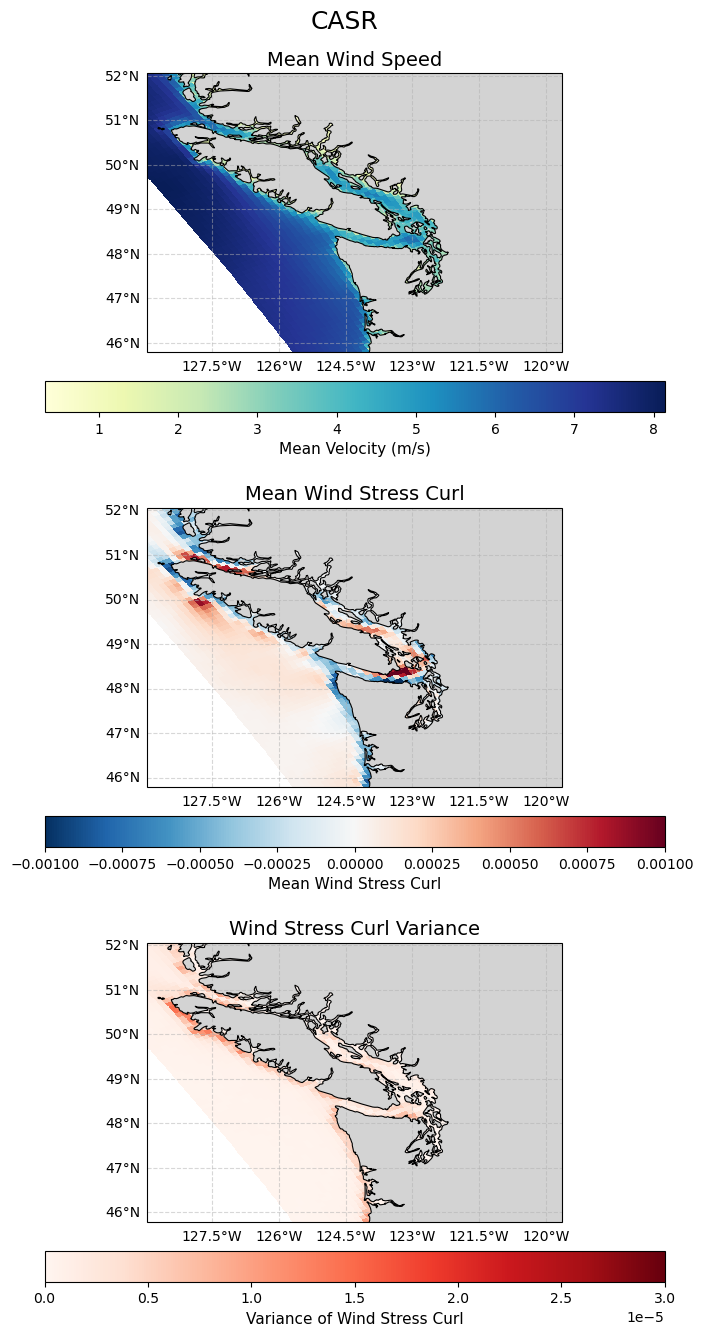

In [12]:

# CASR 

trim_n = 2
ds_casr_trimmed = ds_casr.isel(rlon=slice(trim_n, -trim_n), rlat=slice(trim_n, -trim_n))

lon_casr = ds_casr_trimmed.lon.values
lat_casr = ds_casr_trimmed.lat.values
vel_casr = ds_casr_trimmed.mean_velocity.values
curl_casr = ds_casr_trimmed.mean_ws_casr.values
var_curl_casr = ds_casr_trimmed.var_ws_casr.values

# 【修改点】同样删除了重新计算边界的代码

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 16), subplot_kw={'projection': proj})

def setup_map(ax):
    # 这里使用的是全局的 lon_min, lon_max, lat_min, lat_max
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

# mean velocity
ax1 = axes[0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon_casr, lat_casr, vel_casr, transform=proj, cmap='YlGnBu', shading='auto', zorder=1)
cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
cb1.set_label('Mean Velocity (m/s)', fontsize=11)
ax1.set_title('Mean Wind Speed', fontsize=14)

# mean wind stress curl
ax2 = axes[1]
setup_map(ax2)
pcm2 = ax2.pcolormesh(lon_casr, lat_casr, curl_casr, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
cb2.set_label('Mean Wind Stress Curl', fontsize=11)
ax2.set_title('Mean Wind Stress Curl', fontsize=14)

# variance of wind stress curl
ax3 = axes[2]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon_casr, lat_casr, var_curl_casr, transform=proj, cmap='Reds',
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
cb3.set_label('Variance of Wind Stress Curl', fontsize=11)
ax3.set_title('Wind Stress Curl Variance', fontsize=14)

plt.suptitle('CASR', fontsize=18, y=0.92)
plt.show()

### Compare

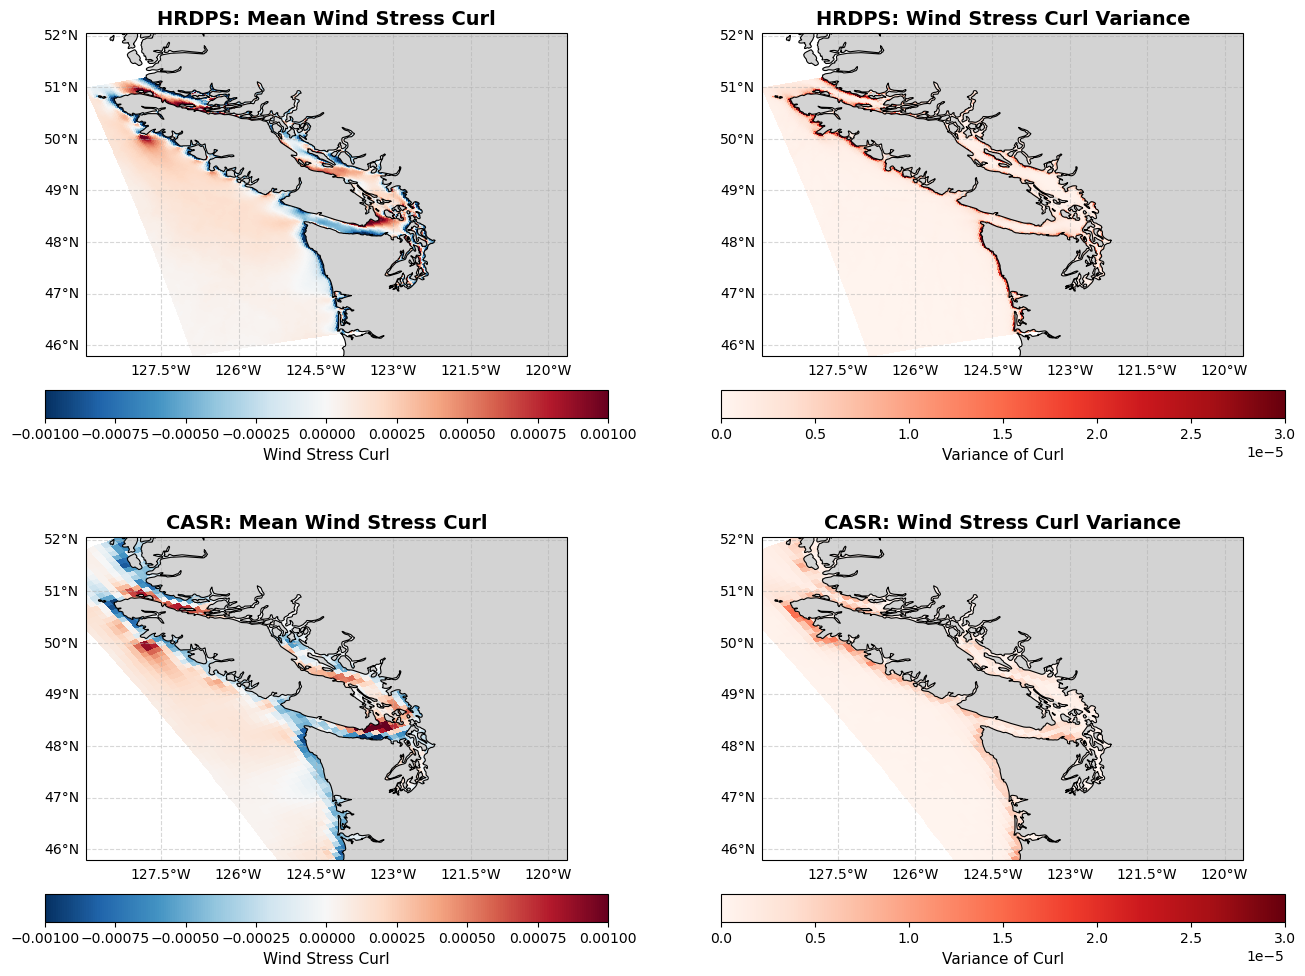

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


trim_n = 5

# HRDPS 
ds_h_trim = ds_hrdps.isel(x=slice(trim_n, -trim_n), y=slice(trim_n, -trim_n))
# 如果你的原始 HRDPS 坐标也有 NaN 报错，可以在这里加上 .ffill().bfill()
lon_h = ds_h_trim.nav_lon.values
lat_h = ds_h_trim.nav_lat.values
curl_h = ds_h_trim.mean_ws_curl.values
var_h = ds_h_trim.var_ws_curl.values

# CASR 
ds_c_trim = ds_casr.isel(rlon=slice(trim_n, -trim_n), rlat=slice(trim_n, -trim_n))
lon_c = ds_c_trim.lon.values
lat_c = ds_c_trim.lat.values
curl_c = ds_c_trim.mean_ws_casr.values
var_c = ds_c_trim.var_ws_casr.values

# 复用全局显示范围 (假设之前已经计算好，如果没有，请确保这里有具体数值)
# 例如: lon_min, lon_max, lat_min, lat_max = -65.0, -50.0, 40.0, 55.0

# visualization

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), subplot_kw={'projection': proj})

# 统一地图设置的辅助函数
def setup_map(ax):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

#  HRDPS Mean Curl
ax1 = axes[0, 0]
setup_map(ax1)
pcm1 = ax1.pcolormesh(lon_h, lat_h, curl_h, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.08)
cb1.set_label('Wind Stress Curl', fontsize=11)
ax1.set_title('HRDPS: Mean Wind Stress Curl', fontsize=14, fontweight='bold')

# HRDPS - Variance
ax2 = axes[0, 1]
setup_map(ax2)
pcm2 = ax2.pcolormesh(lon_h, lat_h, var_h, transform=proj, cmap='Reds', 
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.08)
cb2.set_label('Variance of Curl', fontsize=11)
ax2.set_title('HRDPS: Wind Stress Curl Variance', fontsize=14, fontweight='bold')

# CASR
# CASR Mean Curl
ax3 = axes[1, 0]
setup_map(ax3)
pcm3 = ax3.pcolormesh(lon_c, lat_c, curl_c, transform=proj, cmap='RdBu_r', 
                      vmin=-0.001, vmax=0.001, shading='auto', zorder=1)
cb3 = plt.colorbar(pcm3, ax=ax3, orientation='horizontal', pad=0.08)
cb3.set_label('Wind Stress Curl', fontsize=11)
ax3.set_title('CASR: Mean Wind Stress Curl', fontsize=14, fontweight='bold')

# CASR Variance
ax4 = axes[1, 1]
setup_map(ax4)
pcm4 = ax4.pcolormesh(lon_c, lat_c, var_c, transform=proj, cmap='Reds', 
                      vmin=0, vmax=0.00003, shading='auto', zorder=1)
cb4 = plt.colorbar(pcm4, ax=ax4, orientation='horizontal', pad=0.08)
cb4.set_label('Variance of Curl', fontsize=11)
ax4.set_title('CASR: Wind Stress Curl Variance', fontsize=14, fontweight='bold')

# 调整主标题和子图间距
#plt.suptitle('Comparison of Wind Stress Dynamics: HRDPS vs CASR', fontsize=18, y=0.95)
#plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.show()

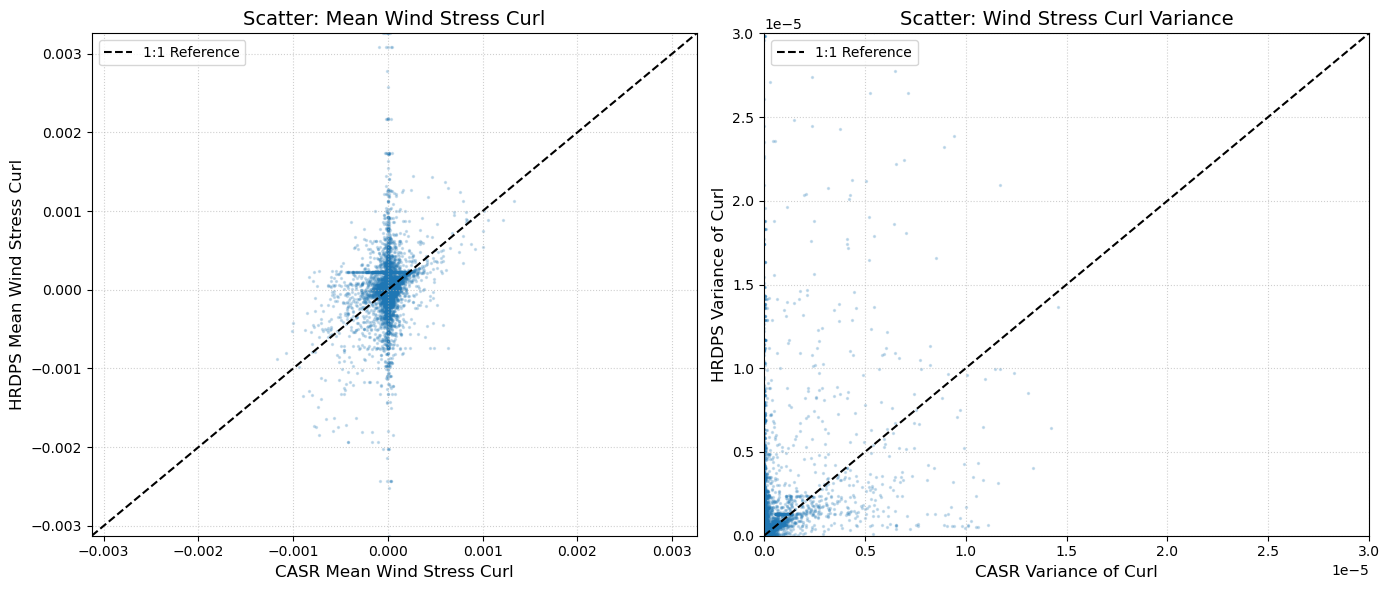

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree



# get rid of nan

# CASR 
casr_mask = ~np.isnan(curl_casr)
c_lon_valid = lon_casr[casr_mask]
c_lat_valid = lat_casr[casr_mask]
c_curl_valid = curl_casr[casr_mask]
c_var_valid = var_curl_casr[casr_mask]

# HRDPS
hrdps_mask = ~np.isnan(curl_h)
h_lon_valid = lon_h[hrdps_mask]
h_lat_valid = lat_h[hrdps_mask]
h_curl_valid = curl_h[hrdps_mask]
h_var_valid = var_h[hrdps_mask]

# matching

#  (N, 2) 
hrdps_coords = np.c_[h_lon_valid, h_lat_valid]
casr_coords = np.c_[c_lon_valid, c_lat_valid]

# find out nearest point
tree = cKDTree(hrdps_coords)
# d 是距离，idx 是 hrdps_coords 中对应的索引位置
distances, indices = tree.query(casr_coords)

# 提取匹配到的 HRDPS 数据
h_curl_matched = h_curl_valid[indices]
h_var_matched = h_var_valid[indices]



# visualization
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))


scatter_kwargs = {'s': 2, 'alpha': 0.2, 'color': '#1f77b4'}
line_kwargs = {'color': 'black', 'linestyle': '--', 'linewidth': 1.5, 'label': '1:1 Reference'}

# wind stress curl mean
ax1 = axes[0]
ax1.scatter(c_curl_valid, h_curl_matched, **scatter_kwargs)

# 计算坐标轴范围（取两者极值以保证图是对称的）
curl_min = min(np.min(c_curl_valid), np.min(h_curl_matched))
curl_max = max(np.max(c_curl_valid), np.max(h_curl_matched))
# 1:1 reference line
ax1.plot([curl_min, curl_max], [curl_min, curl_max], **line_kwargs)

ax1.set_xlim([curl_min, curl_max])
ax1.set_ylim([curl_min, curl_max])
ax1.set_xlabel('CASR Mean Wind Stress Curl', fontsize=12)
ax1.set_ylabel('HRDPS Mean Wind Stress Curl', fontsize=12)
ax1.set_title('Scatter: Mean Wind Stress Curl', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# wind stress curl
ax2 = axes[1]
ax2.scatter(c_var_valid, h_var_matched, **scatter_kwargs)

# 计算坐标轴范围
var_min = 0 
# var_max = max(np.max(c_var_valid), np.max(h_var_matched))
var_max = 3e-5
# 1:1 
ax2.plot([var_min, var_max], [var_min, var_max], **line_kwargs)

ax2.set_xlim([var_min, var_max])
ax2.set_ylim([var_min, var_max])
ax2.set_xlabel('CASR Variance of Curl', fontsize=12)
ax2.set_ylabel('HRDPS Variance of Curl', fontsize=12)
ax2.set_title('Scatter: Wind Stress Curl Variance', fontsize=14)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()